<a href="https://colab.research.google.com/github/venkateshkumarsingaravelu/machine_learning_workshop/blob/main/unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

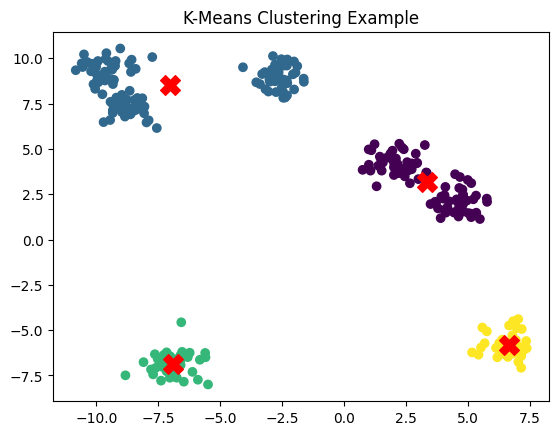

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=7, cluster_std=0.6, random_state=42)

# Create and fit the model
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Plot clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X')
plt.title("K-Means Clustering Example")
plt.show()


In [7]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

X, _ = load_iris(return_X_y=True)

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

print(X2[:5])


[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]]


In [8]:
# DBSCAN (Density‑Based Spatial Clustering of Applications with Noise)
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=200, noise=0.1)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

print(labels[:10])


[0 0 0 1 2 2 1 1 1 2]


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.5)

iso = IsolationForest(contamination=0.05)
labels = iso.fit_predict(X)

print(labels[:20])  # -1 = anomaly, 1 = normal


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


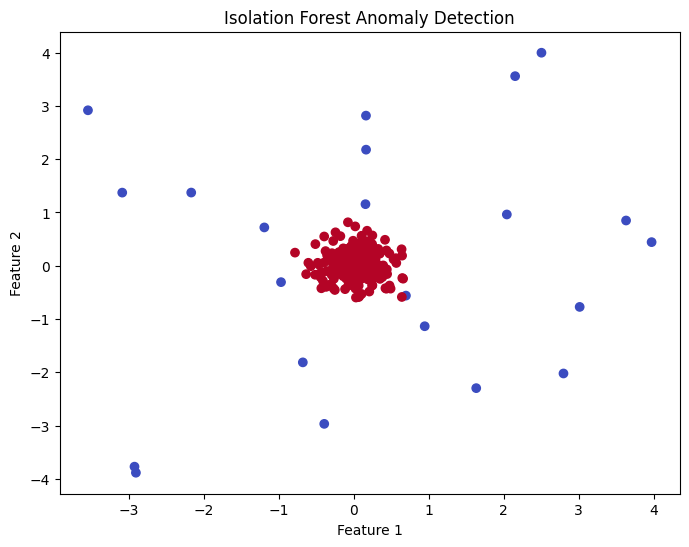

Labels: [1 1 1 1 1 1 1 1 1 1]
Scores: [0.1189275  0.09375515 0.12224514 0.0889054  0.11664767 0.11882039
 0.05775404 0.08109001 0.10974564 0.07633279]


In [10]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create sample dataset
# -----------------------------
rng = np.random.RandomState(42)

# Normal data (clustered around 0)
X_normal = 0.3 * rng.randn(200, 2)

# Add some outliers
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))

# Combine data
X = np.vstack([X_normal, X_outliers])

# -----------------------------
# 2. Train Isolation Forest
# -----------------------------
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,   # 10% anomalies expected
    random_state=42
)

model.fit(X)

# -----------------------------
# 3. Predict anomalies
# -----------------------------
labels = model.predict(X)     # 1 = normal, -1 = anomaly
scores = model.decision_function(X)  # anomaly score

# -----------------------------
# 4. Visualize results
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm')
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Print first 10 predictions
print("Labels:", labels[:10])
print("Scores:", scores[:10])
